In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
df=pd.read_csv("customers.csv")

In [5]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB


In [7]:
df.isnull().sum()

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [8]:
df=df.dropna()

In [13]:
print(df.columns)

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='str')


In [14]:
df=df.drop("ID",axis=1)

In [17]:
df=pd.get_dummies(df,drop_first = True)

In [18]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)

In [19]:
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled_data)

In [20]:
wcss=[]
for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42)
    model.fit(pca_data)
    wcss.append(model.inertia_)

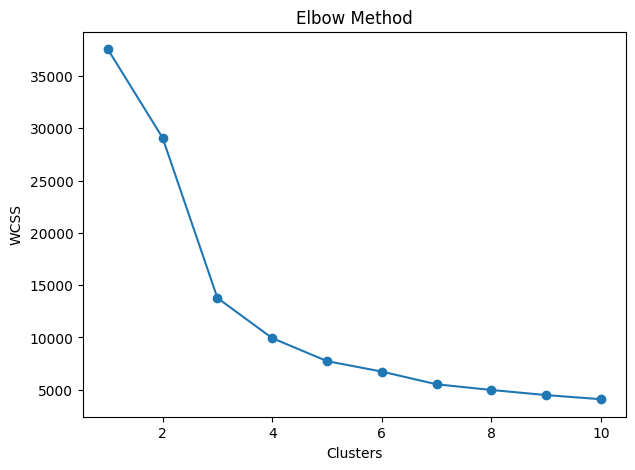

In [21]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    labels=model.fit_predict(pca_data)
    score=silhouette_score(pca_data,labels)
    print(k,score)

2 0.281838906064858
3 0.3745533587202801
4 0.39504507096819724
5 0.4094218279579815
6 0.40568637667881985
7 0.39312119040915866
8 0.3926523467836966
9 0.3675392633334908
10 0.3669660574534834


In [23]:
Kmeans=KMeans(n_clusters=4,random_state=42)
clusters=Kmeans.fit_predict(pca_data)

In [24]:
df["Clusters"]=clusters

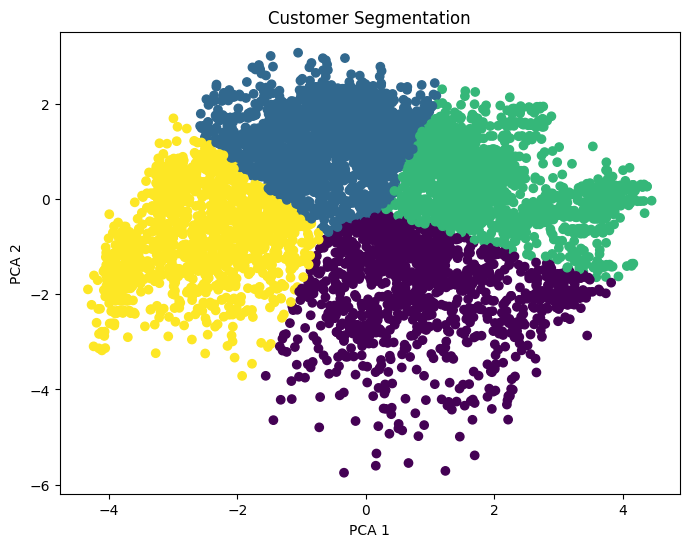

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0],pca_data[:,1],c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation")
plt.show()

In [27]:
df.to_csv("clustered_data.csv",index=False)

In [28]:
df.groupby("Clusters").mean()

,Age,Work_Experience,Family_Size,Gender_Male,Ever_Married_Yes,Graduated_Yes,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,...,Spending_Score_Low,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,Segmentation_B,Segmentation_C,Segmentation_D
Clusters,,,,,,,,,,,,,,,,,,,,,
0,47.834862,2.046706,3.537948,0.689741,0.994996,0.547957,0.055046,0.143453,0.121768,0.322769,...,0.160967,0.095079,0.170976,0.343620,0.022519,0.291910,0.053378,0.337781,0.271059,0.128440
1,38.876845,3.734860,2.033079,0.446310,0.313995,0.783715,0.134860,0.087532,0.169466,0.006616,...,0.965903,0.031043,0.067176,0.015267,0.002545,0.855471,0.015267,0.227990,0.145038,0.237659
2,57.375680,1.989619,2.459219,0.572417,0.994563,0.843796,0.053386,0.047949,0.102818,0.043005,...,0.227385,0.005932,0.021750,0.001977,0.002966,0.957489,0.001977,0.306476,0.494315,0.036085
3,27.300406,2.506766,3.872801,0.551421,0.082544,0.233424,0.103518,0.095399,0.082544,0.012179,...,0.979702,0.118403,0.171177,0.272666,0.024357,0.343708,0.046008,0.066982,0.074425,0.719215


Customer Segmentation using K-Means Clustering and PCA

* Project Overview

This project performs customer segmentation using the K-Means Clustering algorithm, an unsupervised machine learning technique. The dataset is preprocessed, standardized, reduced using Principal Component Analysis (PCA), and then clustered into different customer groups. The Elbow Method and Silhouette Score are used to determine the optimal number of clusters.


* Objectives

- Understand customer behavior using clustering.
- Reduce high-dimensional data using PCA.
- Find the optimal number of clusters.
- Visualize customer segments.
- Generate business insights based on customer groups.


8 Technologies Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


* Project Structure


Customer_Segmentation_Project/
│
├── data/
│   └── customers.csv
│
├── output/
│   ├── clustered_data.csv
│   ├── elbow_plot.png
│   └── pca_plot.png
│
├── notebook.ipynb
├── requirements.txt
└── README.md



* Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Handle Missing Values
5. Remove Unnecessary Columns
6. Encode Categorical Features
7. Standardize Data
8. Apply PCA
9. Find Optimal Clusters using Elbow Method
10. Evaluate using Silhouette Score
11. Apply K-Means Clustering
12. Visualize Clusters
13. Analyze Customer Segments
14. Save Clustered Dataset


* Machine Learning Algorithm

# K-Means Clustering

K-Means is an unsupervised learning algorithm used to divide customers into groups based on similar characteristics.

# Principal Component Analysis (PCA)

PCA reduces the number of features while preserving most of the information, making visualization easier.


* Evaluation Methods

- Elbow Method
- Silhouette Score


* Output

The project generates:

- Clustered customer dataset
- Elbow Method graph
- PCA Cluster Visualization
- Customer Segment Analysis


* Business Insights

The customers can be grouped into different categories such as:

- High Value Customers
- Budget Customers
- Regular Customers
- Premium Customers

These insights help businesses create targeted marketing strategies and improve customer satisfaction.


* Requirements

Install the required libraries using:

    pip install -r requirements.txt


